# Bayesian Classification for Coronary Heart Disease Risk

## Goal

The goal of this notebook is to introduce Bayesian-style supervised learning through a coronary heart disease classification problem.

The project focuses on predicting whether a patient has coronary heart disease using health-related risk factors.

This notebook is an introduction to Bayesian machine learning for me. It uses lightweight models first, then prepares the foundation for larger Bayesian projects using tools such as PyMC later.

In [1]:
import os
import warnings

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.calibration import calibration_curve, CalibratedClassifierCV

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    brier_score_loss,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

c:\Users\ADMIN\AppData\Local\Programs\Python\Python311\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!
  warnings.warn(


In [2]:
path = kagglehub.dataset_download("billbasener/coronary-heart-disease")
print("Dataset downloaded to:", path)

print("Files:")
print(os.listdir(path))

100%|██████████| 7.62k/7.62k [00:00<00:00, 1.04MB/s]

Extracting files...
Dataset downloaded to: C:\Users\ADMIN\.cache\kagglehub\datasets\billbasener\coronary-heart-disease\versions\1
Files:
['CHDdata.csv']


In [3]:
csv_files = [file for file in os.listdir(path) if file.endswith(".csv")]
csv_files

['CHDdata.csv']

In [4]:
csv_path = os.path.join(path, csv_files[0])
df = pd.read_csv(csv_path)

df.head()

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,chd
0,160,12.00,5.73,23.11,Present,49,25.30,97.20,52,1
1,144,0.01,4.41,28.61,Absent,55,28.87,2.06,63,1
2,118,0.08,3.48,32.28,Present,52,29.14,3.81,46,0
3,170,7.50,6.41,38.03,Present,51,31.99,24.26,58,1
4,134,13.60,3.50,27.78,Present,60,25.99,57.34,49,1


## Dataset

This dataset contains patient-level records for coronary heart disease analysis.

Each row represents a patient. The features describe health, lifestyle, and risk-related variables such as blood pressure, tobacco use, LDL cholesterol, adiposity, family history, Type-A behaviour score, obesity, alcohol use, and age.

The target variable is `chd`, where:

- `0` means no coronary heart disease
- `1` means coronary heart disease

This is a supervised binary classification problem.

In [5]:
print("Shape:", df.shape)
df.info()

Shape: (462, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 462 entries, 0 to 461
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sbp        462 non-null    int64  
 1   tobacco    462 non-null    float64
 2   ldl        462 non-null    float64
 3   adiposity  462 non-null    float64
 4   famhist    462 non-null    object 
 5   typea      462 non-null    int64  
 6   obesity    462 non-null    float64
 7   alcohol    462 non-null    float64
 8   age        462 non-null    int64  
 9   chd        462 non-null    int64  
dtypes: float64(5), int64(4), object(1)
memory usage: 36.2+ KB


## Bayesian Learning Intuition

Bayesian learning is based on updating beliefs using evidence.

In general:

```text
posterior ∝ likelihood × prior

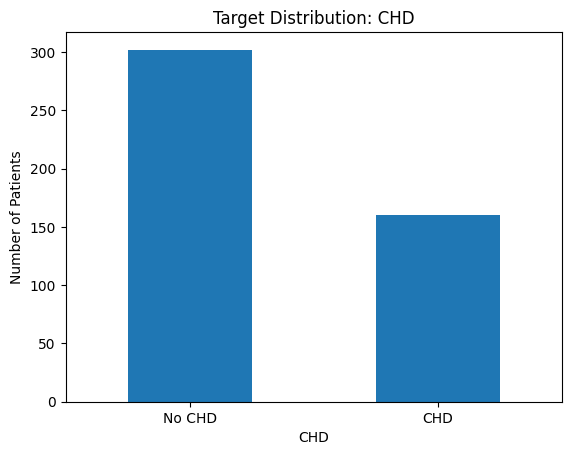

chd
0    302
1    160
Name: count, dtype: int64
chd
0    0.65368
1    0.34632
Name: proportion, dtype: float64


In [6]:
target_counts = df["chd"].value_counts().sort_index()

target_counts.plot(kind="bar")
plt.title("Target Distribution: CHD")
plt.xlabel("CHD")
plt.ylabel("Number of Patients")
plt.xticks(ticks=[0, 1], labels=["No CHD", "CHD"], rotation=0)
plt.show()

print(target_counts)
print(df["chd"].value_counts(normalize=True).sort_index())

In [7]:
target_col = "chd"

numeric_cols = df.drop(columns=[target_col]).select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.drop(columns=[target_col]).select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['sbp', 'tobacco', 'ldl', 'adiposity', 'typea', 'obesity', 'alcohol', 'age']
Categorical columns: ['famhist']


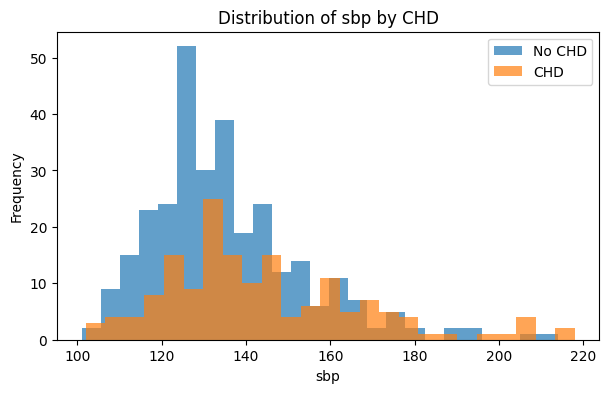

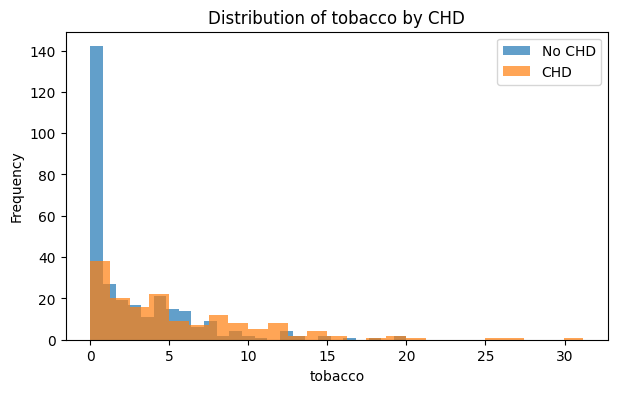

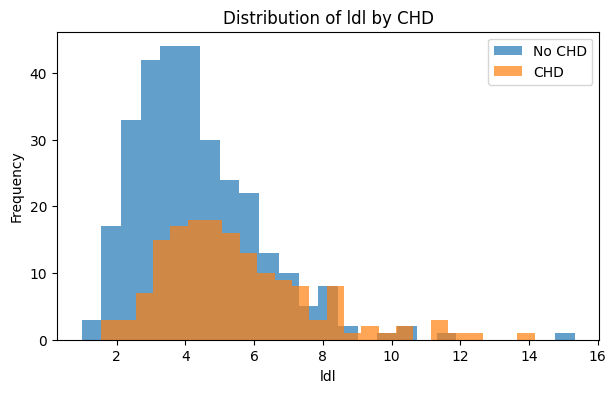

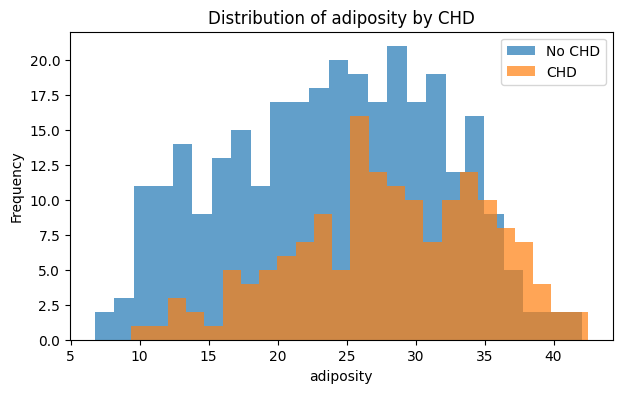

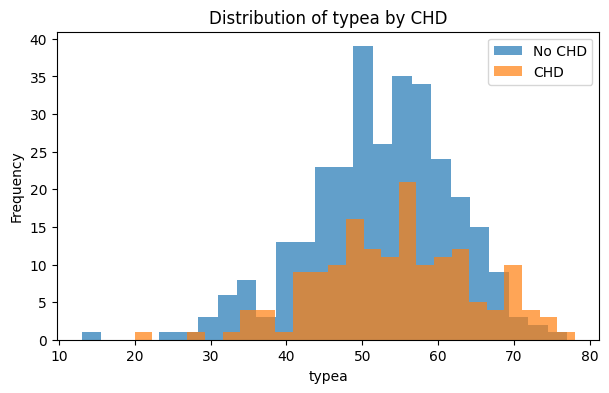

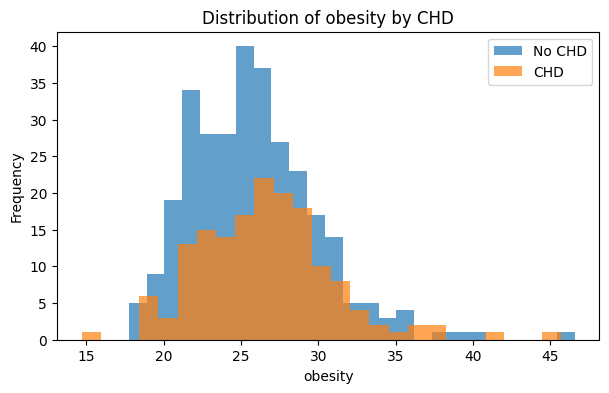

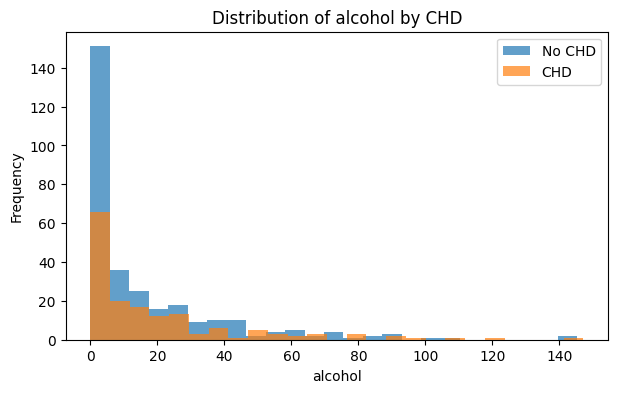

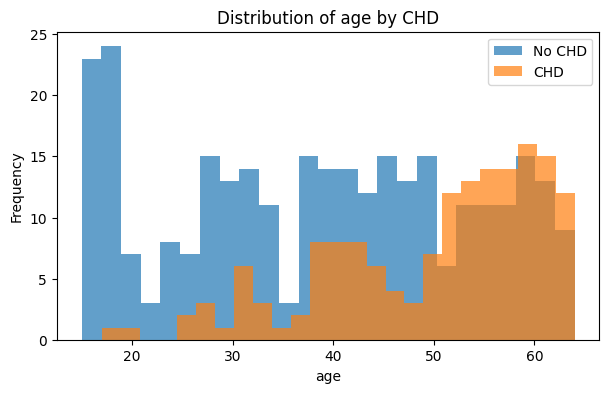

In [8]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[df[target_col] == 0][col], bins=25, alpha=0.7, label="No CHD")
    plt.hist(df[df[target_col] == 1][col], bins=25, alpha=0.7, label="CHD")
    plt.title(f"Distribution of {col} by CHD")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

## Numerical Feature Distributions

The numerical feature plots compare the distribution of each variable between patients with and without CHD.

This is useful for Naive Bayes because Gaussian Naive Bayes models each numerical feature as a class-conditional distribution.

In simple terms, the model asks:

```text
How likely is this feature value if the patient has CHD?
How likely is this feature value if the patient does not have CHD?

chd,0,1
famhist,,
Absent,0.762963,0.237037
Present,0.500000,0.500000


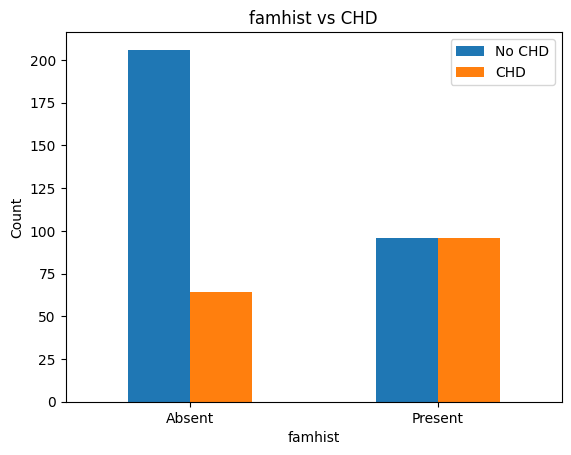

In [9]:
for col in categorical_cols:
    display(pd.crosstab(df[col], df[target_col], normalize="index"))
    
    pd.crosstab(df[col], df[target_col]).plot(kind="bar")
    plt.title(f"{col} vs CHD")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.legend(["No CHD", "CHD"])
    plt.show()

## Categorical Feature Analysis

Categorical features are useful because they can show group-level differences in CHD rate.

For example, if family history is available, we can compare the CHD rate between patients with and without family history of heart disease.

In Bayesian terms, categorical features help update the probability of CHD by providing evidence about group membership.

## Train-Test Split

The dataset is split into training and testing sets using stratified sampling.

Stratification preserves the CHD class ratio in both sets. This is important because the class ratio represents the prior class distribution, and we want both training and testing data to have similar class balance.

The model learns from the training data and is evaluated on the unseen test data.

In [10]:
X = df.drop(columns=[target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (462, 9)
y shape: (462,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

Train shape: (346, 9)
Test shape: (116, 9)

Train target distribution:
chd
0    0.653179
1    0.346821
Name: proportion, dtype: float64

Test target distribution:
chd
0    0.655172
1    0.344828
Name: proportion, dtype: float64


## Preprocessing

The preprocessing pipeline standardizes numerical features and one-hot encodes categorical features.

Standardization is useful because it puts numerical variables on a similar scale. One-hot encoding converts categorical variables into numerical indicator columns that machine learning models can use.

Although Gaussian Naive Bayes can work with raw numerical features, standardizing the features makes the comparison with logistic regression cleaner and keeps the modelling pipeline consistent.

In [12]:
numeric_features = numeric_cols
categorical_features = categorical_cols

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_processed = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

X_train_processed.head()

,sbp,tobacco,ldl,adiposity,typea,obesity,alcohol,age,famhist_Present
386,0.276885,-0.778383,-0.267572,0.571250,-0.091136,-1.025821,-0.700370,1.135337,1.0
240,0.082066,0.390436,-0.554092,0.522768,1.751709,0.328842,0.160501,0.167273,0.0
132,-0.210163,-0.441224,-0.481248,-0.490108,-1.217320,-0.313755,-0.226187,-0.869939,0.0
199,0.471705,-0.778383,-0.029615,-0.115357,-0.295897,-0.174815,-0.528366,-1.077381,0.0
275,-0.112753,1.199618,-0.015046,1.415095,-1.524461,0.147724,-0.581717,1.411927,1.0


## Prior-Only Baseline

The prior-only model predicts using only the class distribution from the training data.

This model does not look at patient features. It represents the baseline belief before observing any individual patient information.

In Bayesian terms, this is similar to starting with the prior probability of CHD. Any useful model should improve on this baseline by updating the prediction using evidence from the features.


In [13]:
prior_model = DummyClassifier(strategy="prior", random_state=42)
prior_model.fit(X_train_processed, y_train)

prior_probs = prior_model.predict_proba(X_test_processed)[:, 1]
prior_preds = prior_model.predict(X_test_processed)

print("Prior probability of CHD from training data:")
print(prior_model.class_prior_)

print("\nClassification report:")
print(classification_report(y_test, prior_preds, digits=4))

print("ROC-AUC:", roc_auc_score(y_test, prior_probs))
print("PR-AUC:", average_precision_score(y_test, prior_probs))
print("Brier Score:", brier_score_loss(y_test, prior_probs))

Prior probability of CHD from training data:
[0.65317919 0.34682081]

Classification report:
              precision    recall  f1-score   support

           0     0.6552    1.0000    0.7917        76
           1     0.0000    0.0000    0.0000        40

    accuracy                         0.6552       116
   macro avg     0.3276    0.5000    0.3958       116
weighted avg     0.4293    0.6552    0.5187       116

ROC-AUC: 0.5
PR-AUC: 0.3448275862068966
Brier Score: 0.22592549493571573


## Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classifier based on Bayes' theorem.

It estimates the probability of each class using:

```text
posterior ∝ prior × likelihood

In [14]:
gnb = GaussianNB()

gnb.fit(X_train_processed, y_train)

gnb_probs = gnb.predict_proba(X_test_processed)[:, 1]
gnb_preds = gnb.predict(X_test_processed)

In [15]:
print("Gaussian Naive Bayes Results")
print(confusion_matrix(y_test, gnb_preds))
print(classification_report(y_test, gnb_preds, digits=4))

print("ROC-AUC:", roc_auc_score(y_test, gnb_probs))
print("PR-AUC:", average_precision_score(y_test, gnb_probs))
print("Brier Score:", brier_score_loss(y_test, gnb_probs))

Gaussian Naive Bayes Results
[[54 22]
 [10 30]]
              precision    recall  f1-score   support

           0     0.8438    0.7105    0.7714        76
           1     0.5769    0.7500    0.6522        40

    accuracy                         0.7241       116
   macro avg     0.7103    0.7303    0.7118       116
weighted avg     0.7517    0.7241    0.7303       116

ROC-AUC: 0.7542763157894737
PR-AUC: 0.5805812861654889
Brier Score: 0.22741679363361345


## Logistic Regression Baseline

Logistic regression is included as a standard supervised classification baseline.

Although it is not Bayesian in this notebook, it is useful because it also outputs predicted probabilities. This lets us compare Gaussian Naive Bayes against a common probability-based classifier.

If Naive Bayes performs competitively, it suggests that the Bayesian-style assumptions are useful for this dataset. If logistic regression performs better, it may mean that the independence assumptions of Naive Bayes are too restrictive.

In [16]:
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight=None,
    random_state=42
)

log_reg.fit(X_train_processed, y_train)

log_probs = log_reg.predict_proba(X_test_processed)[:, 1]
log_preds = log_reg.predict(X_test_processed)

In [17]:
print("Logistic Regression Results")
print(confusion_matrix(y_test, log_preds))
print(classification_report(y_test, log_preds, digits=4))

print("ROC-AUC:", roc_auc_score(y_test, log_probs))
print("PR-AUC:", average_precision_score(y_test, log_probs))
print("Brier Score:", brier_score_loss(y_test, log_probs))

Logistic Regression Results
[[62 14]
 [16 24]]
              precision    recall  f1-score   support

           0     0.7949    0.8158    0.8052        76
           1     0.6316    0.6000    0.6154        40

    accuracy                         0.7414       116
   macro avg     0.7132    0.7079    0.7103       116
weighted avg     0.7386    0.7414    0.7397       116

ROC-AUC: 0.7967105263157894
PR-AUC: 0.6724740058601114
Brier Score: 0.1726472773710833


In [18]:
def evaluate_classifier(name, y_true, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    
    return {
        "Model": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_true, preds),
        "Precision": precision_score(y_true, preds, zero_division=0),
        "Recall": recall_score(y_true, preds, zero_division=0),
        "F1": f1_score(y_true, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, probs),
        "PR-AUC": average_precision_score(y_true, probs),
        "Brier Score": brier_score_loss(y_true, probs),
    }



In [19]:
results_df = pd.DataFrame([
    evaluate_classifier("Prior Only", y_test, prior_probs),
    evaluate_classifier("Gaussian Naive Bayes", y_test, gnb_probs),
    evaluate_classifier("Logistic Regression", y_test, log_probs),
])

results_df

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier Score
0,Prior Only,0.5,0.655172,0.000000,0.00,0.000000,0.500000,0.344828,0.225925
1,Gaussian Naive Bayes,0.5,0.724138,0.576923,0.75,0.652174,0.754276,0.580581,0.227417
2,Logistic Regression,0.5,0.741379,0.631579,0.60,0.615385,0.796711,0.672474,0.172647


## Model Comparison

The models are compared using accuracy, precision, recall, F1-score, ROC-AUC, PR-AUC, and Brier score.

Accuracy measures overall correctness, but it can hide poor performance on the positive class. Precision and recall are more useful for understanding CHD detection behaviour.

ROC-AUC measures ranking ability across thresholds. PR-AUC focuses more directly on positive-class prediction quality. Brier score measures probability error, where lower values indicate better probability estimates.

Logistic Regression achieved the best ROC-AUC with a score of 0.7967. It also achieved the best PR-AUC with a score of 0.6725 and the lowest Brier score of 0.1726.

Gaussian Naive Bayes achieved a ROC-AUC of 0.7543 and a PR-AUC of 0.5806. It had the highest recall for the CHD class at the default 0.5 threshold, with recall of 0.7500. This means it was better at capturing positive CHD cases, but it also produced more false positives.

The prior-only model performed as expected. It used only the class distribution and did not use patient features, so its ROC-AUC was 0.5000. This represents a basic baseline with no ranking ability.

Overall, Logistic Regression produced the strongest probability-based performance, while Gaussian Naive Bayes was still useful as an interpretable Bayesian-style model for understanding priors, likelihoods, and posterior probabilities.

This comparison helps separate two ideas:

- How well the model ranks higher-risk patients
- How reliable the predicted probabilities are

<Figure size 700x500 with 0 Axes>

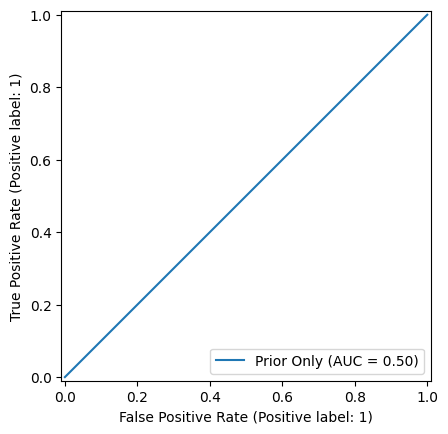

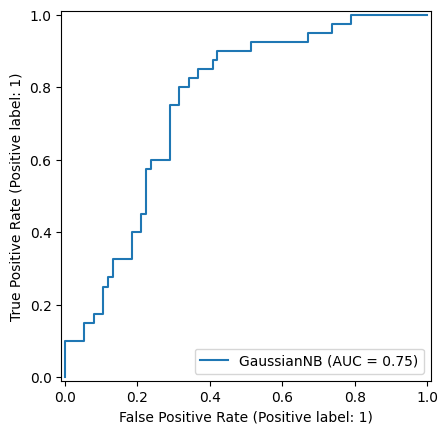

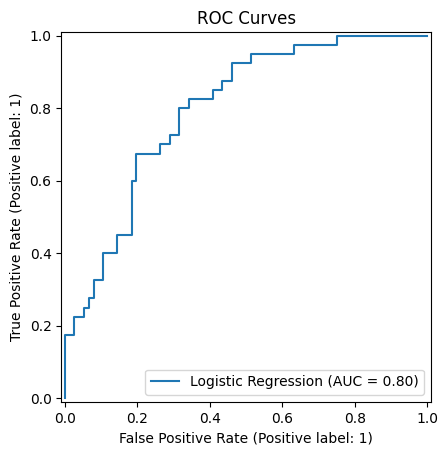

In [20]:
plt.figure(figsize=(7, 5))
for name, probs in {
    "Prior Only": prior_probs,
    "GaussianNB": gnb_probs,
    "Logistic Regression": log_probs,
}.items():
    RocCurveDisplay.from_predictions(y_test, probs, name=name)

plt.title("ROC Curves")
plt.show()

<Figure size 700x500 with 0 Axes>

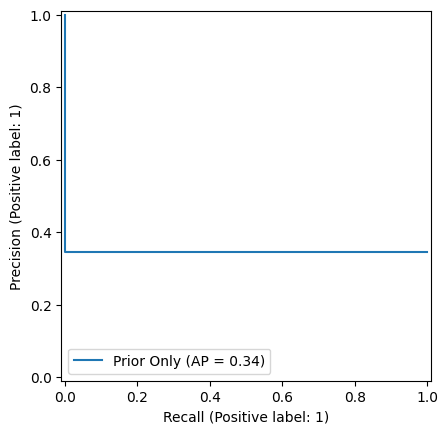

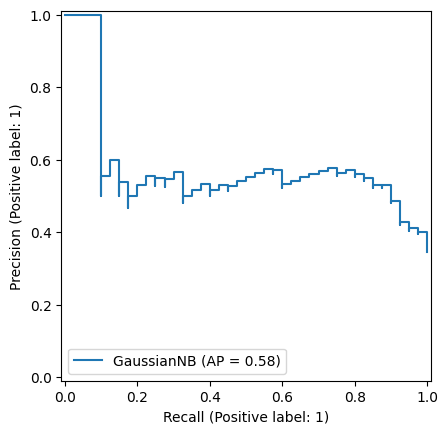

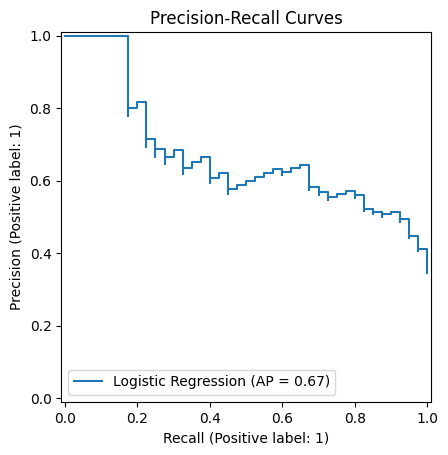

In [21]:
plt.figure(figsize=(7, 5))
for name, probs in {
    "Prior Only": prior_probs,
    "GaussianNB": gnb_probs,
    "Logistic Regression": log_probs,
}.items():
    PrecisionRecallDisplay.from_predictions(y_test, probs, name=name)

plt.title("Precision-Recall Curves")
plt.show()

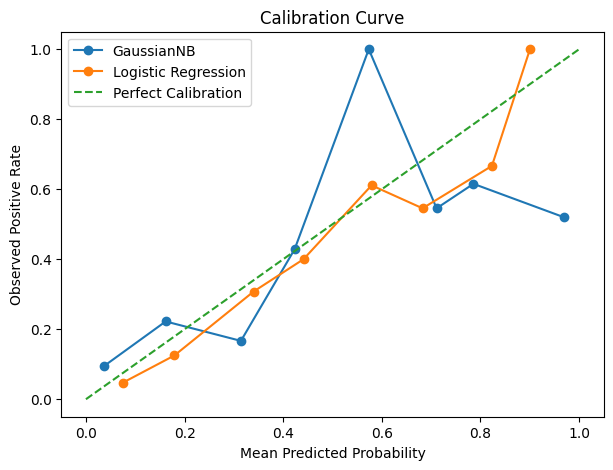

In [22]:
def plot_calibration_curve(y_true, prob_dict, n_bins=8):
    plt.figure(figsize=(7, 5))
    
    for name, probs in prob_dict.items():
        prob_true, prob_pred = calibration_curve(y_true, probs, n_bins=n_bins)
        plt.plot(prob_pred, prob_true, marker="o", label=name)
    
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Calibration")
    plt.title("Calibration Curve")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Observed Positive Rate")
    plt.legend()
    plt.show()

plot_calibration_curve(
    y_test,
    {
        "GaussianNB": gnb_probs,
        "Logistic Regression": log_probs,
    }
)

## Calibrated Gaussian Naive Bayes

Gaussian Naive Bayes can sometimes produce poorly calibrated probabilities because its feature independence assumption is often unrealistic.

Calibration adjusts the predicted probabilities after model training so that they better match observed outcome frequencies.

In this notebook, isotonic calibration is applied to Gaussian Naive Bayes using cross-validation on the training data.

After calibration, the Brier score changed from 0.2274 to 0.1907.

This indicates that calibration improved the probability quality of Naive Bayes on this test set. The calibrated model produced probabilities with lower overall error, although its default-threshold classification performance became weaker.

The uncalibrated Gaussian Naive Bayes model had higher recall and F1-score at the 0.5 threshold, while the calibrated version produced more reliable probability estimates. This shows that better probability calibration does not always mean better classification performance at a fixed threshold.

In [23]:
calibrated_gnb = CalibratedClassifierCV(
    estimator=GaussianNB(),
    method="isotonic",
    cv=5
)

calibrated_gnb.fit(X_train_processed, y_train)

cal_gnb_probs = calibrated_gnb.predict_proba(X_test_processed)[:, 1]
cal_gnb_preds = (cal_gnb_probs >= 0.5).astype(int)

In [24]:
print("Calibrated Gaussian Naive Bayes Results")
print(confusion_matrix(y_test, cal_gnb_preds))
print(classification_report(y_test, cal_gnb_preds, digits=4))

print("ROC-AUC:", roc_auc_score(y_test, cal_gnb_probs))
print("PR-AUC:", average_precision_score(y_test, cal_gnb_probs))
print("Brier Score:", brier_score_loss(y_test, cal_gnb_probs))

Calibrated Gaussian Naive Bayes Results
[[58 18]
 [19 21]]
              precision    recall  f1-score   support

           0     0.7532    0.7632    0.7582        76
           1     0.5385    0.5250    0.5316        40

    accuracy                         0.6810       116
   macro avg     0.6459    0.6441    0.6449       116
weighted avg     0.6792    0.6810    0.6801       116

ROC-AUC: 0.7539473684210527
PR-AUC: 0.5819569316109318
Brier Score: 0.19071483453094873


In [25]:
results_df = pd.DataFrame([
    evaluate_classifier("Prior Only", y_test, prior_probs),
    evaluate_classifier("Gaussian Naive Bayes", y_test, gnb_probs),
    evaluate_classifier("Calibrated GaussianNB", y_test, cal_gnb_probs),
    evaluate_classifier("Logistic Regression", y_test, log_probs),
])

results_df

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Brier Score
0,Prior Only,0.5,0.655172,0.000000,0.000,0.000000,0.500000,0.344828,0.225925
1,Gaussian Naive Bayes,0.5,0.724138,0.576923,0.750,0.652174,0.754276,0.580581,0.227417
2,Calibrated GaussianNB,0.5,0.681034,0.538462,0.525,0.531646,0.753947,0.581957,0.190715
3,Logistic Regression,0.5,0.741379,0.631579,0.600,0.615385,0.796711,0.672474,0.172647


In [26]:
def threshold_report(y_true, probs, thresholds):
    rows = []
    
    for threshold in thresholds:
        preds = (probs >= threshold).astype(int)
        rows.append({
            "Threshold": threshold,
            "Predicted Positives": preds.sum(),
            "Accuracy": accuracy_score(y_true, preds),
            "Precision": precision_score(y_true, preds, zero_division=0),
            "Recall": recall_score(y_true, preds, zero_division=0),
            "F1": f1_score(y_true, preds, zero_division=0),
        })
    
    return pd.DataFrame(rows)

thresholds = np.round(np.arange(0.1, 0.91, 0.1), 2)

gnb_thresholds = threshold_report(y_test, gnb_probs, thresholds)
log_thresholds = threshold_report(y_test, log_probs, thresholds)
cal_gnb_thresholds = threshold_report(y_test, cal_gnb_probs, thresholds)

gnb_thresholds

,Threshold,Predicted Positives,Accuracy,Precision,Recall,F1
0,0.1,78,0.620690,0.474359,0.925,0.627119
1,0.2,65,0.681034,0.523077,0.850,0.647619
2,0.3,62,0.706897,0.548387,0.850,0.666667
3,0.4,57,0.715517,0.561404,0.800,0.659794
4,0.5,52,0.724138,0.576923,0.750,0.652174
5,0.6,49,0.698276,0.551020,0.675,0.606742
6,0.7,44,0.689655,0.545455,0.600,0.571429
7,0.8,28,0.655172,0.500000,0.350,0.411765
8,0.9,24,0.672414,0.541667,0.325,0.406250


In [27]:
cal_gnb_thresholds

,Threshold,Predicted Positives,Accuracy,Precision,Recall,F1
0,0.1,99,0.474138,0.393939,0.975,0.561151
1,0.2,91,0.525862,0.417582,0.950,0.580153
2,0.3,68,0.672414,0.514706,0.875,0.648148
3,0.4,51,0.715517,0.568627,0.725,0.637363
4,0.5,39,0.681034,0.538462,0.525,0.531646
5,0.6,28,0.620690,0.428571,0.300,0.352941
6,0.7,13,0.681034,0.615385,0.200,0.301887
7,0.8,0,0.655172,0.000000,0.000,0.000000
8,0.9,0,0.655172,0.000000,0.000,0.000000


In [28]:
log_thresholds

,Threshold,Predicted Positives,Accuracy,Precision,Recall,F1
0,0.1,100,0.482759,0.400000,1.000,0.571429
1,0.2,79,0.629310,0.481013,0.950,0.638655
2,0.3,70,0.655172,0.500000,0.875,0.636364
3,0.4,54,0.706897,0.555556,0.750,0.638298
4,0.5,38,0.741379,0.631579,0.600,0.615385
5,0.6,25,0.715517,0.640000,0.400,0.492308
6,0.7,12,0.706897,0.750000,0.225,0.346154
7,0.8,8,0.706897,0.875000,0.175,0.291667
8,0.9,1,0.663793,1.000000,0.025,0.048780


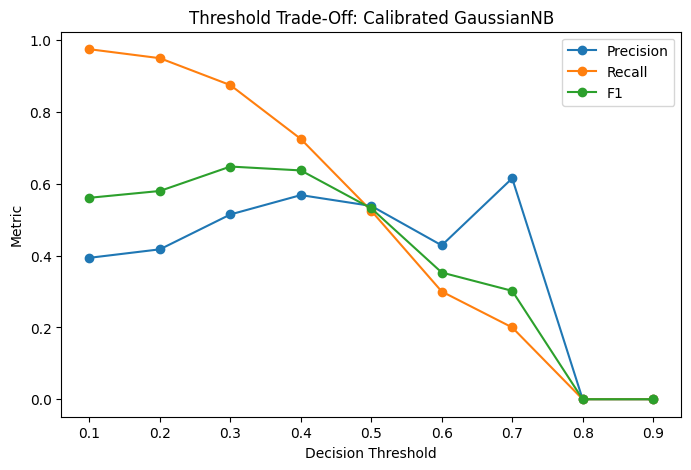

,Threshold,Predicted Positives,Accuracy,Precision,Recall,F1
0,0.1,99,0.474138,0.393939,0.975,0.561151
1,0.2,91,0.525862,0.417582,0.950,0.580153
2,0.3,68,0.672414,0.514706,0.875,0.648148
3,0.4,51,0.715517,0.568627,0.725,0.637363
4,0.5,39,0.681034,0.538462,0.525,0.531646
5,0.6,28,0.620690,0.428571,0.300,0.352941
6,0.7,13,0.681034,0.615385,0.200,0.301887
7,0.8,0,0.655172,0.000000,0.000,0.000000
8,0.9,0,0.655172,0.000000,0.000,0.000000


In [29]:
best_probs = cal_gnb_probs
best_model_name = "Calibrated GaussianNB"

best_thresholds = threshold_report(y_test, best_probs, thresholds)

plt.figure(figsize=(8, 5))
plt.plot(best_thresholds["Threshold"], best_thresholds["Precision"], marker="o", label="Precision")
plt.plot(best_thresholds["Threshold"], best_thresholds["Recall"], marker="o", label="Recall")
plt.plot(best_thresholds["Threshold"], best_thresholds["F1"], marker="o", label="F1")
plt.title(f"Threshold Trade-Off: {best_model_name}")
plt.xlabel("Decision Threshold")
plt.ylabel("Metric")
plt.legend()
plt.show()

best_thresholds

## Threshold Tuning

The default classification threshold is 0.5, but this is not always the best threshold.

For risk prediction problems, changing the threshold changes the behaviour of the model:

- Lower threshold: more patients are predicted as positive, increasing recall but usually reducing precision.
- Higher threshold: fewer patients are predicted as positive, increasing precision but usually reducing recall.

This is important because different real-world goals require different thresholds. If the goal is early screening, higher recall may be preferred. If the goal is avoiding unnecessary follow-up, higher precision may be preferred.

## Uncertainty-Aware Prediction

A probability-based model can provide more information than a hard class label.

Predictions close to 0 or 1 are more confident, while predictions close to 0.5 are more uncertain.

In this notebook, uncertainty is measured using:

```text
uncertainty = 1 - abs(probability - 0.5) × 2

In [30]:
risk_df = X_test.copy()
risk_df["ActualCHD"] = y_test.values
risk_df["GaussianNB_Prob"] = gnb_probs
risk_df["CalibratedGNB_Prob"] = cal_gnb_probs
risk_df["LogReg_Prob"] = log_probs

risk_df["PredictionUncertainty"] = 1 - np.abs(risk_df["CalibratedGNB_Prob"] - 0.5) * 2

risk_df[["ActualCHD", "CalibratedGNB_Prob", "PredictionUncertainty"]].head()

,ActualCHD,CalibratedGNB_Prob,PredictionUncertainty
8,0,0.139011,0.278022
237,0,0.636496,0.727007
79,0,0.389719,0.779438
89,0,0.269104,0.538208
96,0,0.261961,0.523922


In [31]:
most_uncertain = risk_df.sort_values("PredictionUncertainty", ascending=False).head(10)
most_uncertain

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,ActualCHD,GaussianNB_Prob,CalibratedGNB_Prob,LogReg_Prob,PredictionUncertainty
258,138,12.00,5.13,28.34,Absent,59,24.49,32.81,58,1,0.761929,0.499605,0.588191,0.999210
83,148,12.20,3.79,34.15,Absent,57,26.38,14.40,57,1,0.791215,0.499605,0.483758,0.999210
379,154,4.50,4.68,39.97,Absent,61,33.17,1.54,64,1,0.733406,0.499010,0.521104,0.998020
389,164,5.60,3.17,30.98,Present,44,25.99,43.20,53,1,0.729877,0.497376,0.429834,0.994751
302,170,0.00,3.12,37.15,Absent,47,35.42,0.00,53,0,0.758637,0.513119,0.206604,0.973763
28,144,4.09,5.55,31.40,Present,60,29.43,5.55,56,0,0.730183,0.536695,0.673433,0.926611
357,136,6.60,6.08,32.74,Absent,64,33.28,2.72,49,0,0.721720,0.458636,0.478838,0.917272
118,150,3.50,6.99,25.39,Present,50,23.35,23.48,61,1,0.687313,0.455981,0.734527,0.911963
264,132,9.90,4.63,27.86,Present,46,23.39,0.51,52,1,0.672014,0.453549,0.542231,0.907098
9,132,0.00,5.80,30.96,Present,69,30.11,0.00,53,1,0.747801,0.548794,0.642175,0.902413


In [32]:
highest_risk = risk_df.sort_values("CalibratedGNB_Prob", ascending=False).head(10)
highest_risk

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,ActualCHD,GaussianNB_Prob,CalibratedGNB_Prob,LogReg_Prob,PredictionUncertainty
407,200,19.20,4.43,40.60,Present,55,32.04,36.00,60,1,0.999986,0.763889,0.851193,0.472222
161,208,27.40,3.12,26.63,Absent,66,27.45,33.07,62,1,1.000000,0.763889,0.886888,0.472222
125,123,8.60,11.17,35.28,Present,70,33.14,0.00,59,1,0.999440,0.763889,0.923155,0.472222
410,178,20.00,9.78,33.55,Absent,37,27.29,2.88,62,1,0.999970,0.763889,0.829681,0.472222
169,162,5.30,7.95,33.58,Present,58,36.06,8.23,48,0,0.987225,0.743056,0.732718,0.513889
26,118,6.00,9.65,33.91,Absent,60,38.80,0.00,48,0,0.991036,0.743056,0.583585,0.513889
129,152,12.18,4.04,37.83,Present,63,34.57,4.17,64,0,0.990077,0.743056,0.804017,0.513889
255,164,13.02,6.26,29.38,Present,47,22.75,37.03,54,1,0.981404,0.735864,0.737557,0.528272
404,160,1.15,10.19,39.71,Absent,31,31.65,20.52,57,0,0.981640,0.735703,0.417835,0.528595
352,176,1.20,8.28,36.16,Present,42,27.81,11.60,58,1,0.971553,0.735703,0.668510,0.528595


In [33]:
lowest_risk = risk_df.sort_values("CalibratedGNB_Prob", ascending=True).head(10)
lowest_risk

,sbp,tobacco,ldl,adiposity,famhist,typea,obesity,alcohol,age,ActualCHD,GaussianNB_Prob,CalibratedGNB_Prob,LogReg_Prob,PredictionUncertainty
297,136,0.00,2.28,18.14,Absent,55,22.59,0.00,17,0,0.000843,0.02,0.047762,0.04
42,120,0.00,1.07,16.02,Absent,47,22.15,0.00,15,0,0.000439,0.02,0.024107,0.04
266,118,0.12,4.16,9.37,Absent,57,19.61,0.00,17,0,0.000477,0.02,0.078308,0.04
48,114,0.00,1.94,11.02,Absent,54,20.17,38.98,16,0,0.000500,0.02,0.038910,0.04
451,120,0.00,2.77,13.35,Absent,67,23.37,1.03,18,0,0.001014,0.02,0.081482,0.04
296,132,0.10,3.28,10.73,Absent,73,20.42,0.00,17,0,0.001056,0.02,0.117004,0.04
251,128,0.00,6.34,11.87,Absent,57,23.14,0.00,17,0,0.001176,0.02,0.124099,0.04
239,124,0.00,3.23,9.64,Absent,59,22.70,0.00,16,0,0.000329,0.02,0.070881,0.04
90,116,1.03,2.83,10.85,Absent,45,21.59,1.75,21,0,0.000732,0.02,0.050879,0.04
430,118,0.00,3.89,15.96,Absent,65,20.18,0.00,16,0,0.000977,0.02,0.077335,0.04
